In [1]:
! pip install quimb --quiet

In [2]:
import numpy as np
import quimb
import quimb.tensor as qtn

# Matrix Singular Value Decomposition Example:


In [3]:
M= np.random.rand(4,4)
print(M)


[[0.91658447 0.80655565 0.68270414 0.50163775]
 [0.15608152 0.12584338 0.84731238 0.98784205]
 [0.35006942 0.25622187 0.55628351 0.2862888 ]
 [0.69202722 0.48576772 0.0205493  0.52869218]]


In [4]:
u, s, v= np.linalg.svd(M)
print('The matrix U is')
print(u)
print('--------------------------------')
print('The matrix S is')
print(np.diag(s))
print('--------------------------------')
print('The matrix V is')
print(v)

The matrix U is
[[-0.67205198  0.39673128  0.41617011  0.46663998]
 [-0.51931568 -0.79762151 -0.26029321  0.16235328]
 [-0.34210036 -0.09152144  0.45249622 -0.81843652]
 [-0.40202576  0.44500341 -0.74451129 -0.29334315]]
--------------------------------
The matrix S is
[[2.13145499 0.         0.         0.        ]
 [0.         0.88270454 0.         0.        ]
 [0.         0.         0.43718938 0.        ]
 [0.         0.         0.         0.05805989]]
--------------------------------
The matrix V is
[[-0.51374279 -0.41771677 -0.51486023 -0.54451813]
 [ 0.58350144  0.46712003 -0.50611709 -0.43031435]
 [-0.03657199  0.13080842  0.68617493 -0.7146437 ]
 [-0.6278988   0.76824524 -0.08904159  0.08725796]]


In [5]:
rs=np.zeros((4, 4))
for  i in range(len(np.diag(s))-1):
     for j in range(len(np.diag(s)[i])):
         if np.diag(s)[i][j]!=0:
            rs[i][j]=np.diag(s)[i][j]

print(rs)

[[2.13145499 0.         0.         0.        ]
 [0.         0.88270454 0.         0.        ]
 [0.         0.         0.43718938 0.        ]
 [0.         0.         0.         0.        ]]


In [6]:
rm= np.dot(u, np.dot(rs, v))
print(rm)

[[0.93359618 0.78574153 0.68511654 0.49927366]
 [0.16200023 0.11860173 0.8481517  0.98701954]
 [0.32023272 0.2927276  0.5520524  0.29043516]
 [0.68133318 0.49885206 0.01903279 0.53017831]]


In [7]:
distmat=rm-M
distant=(np.linalg.norm(distmat))**2
print(f'Distant between two matrices:{distant}.')
print(f'Squared truncated value:{s[3]**2}')

Distant between two matrices:0.003370950816155626.
Squared truncated value:0.0033709508161556285


# MPS demonstration:

We take a 3-qubit quantum state, i.e., a numpy array with 8 entries.

In [8]:
n = 3
psi = np.random.rand(2**n)
psi = psi / np.linalg.norm(psi)  # random, normalized state vector
psi = np.reshape(psi, (2, 2, 2))
psi.shape

(2, 2, 2)

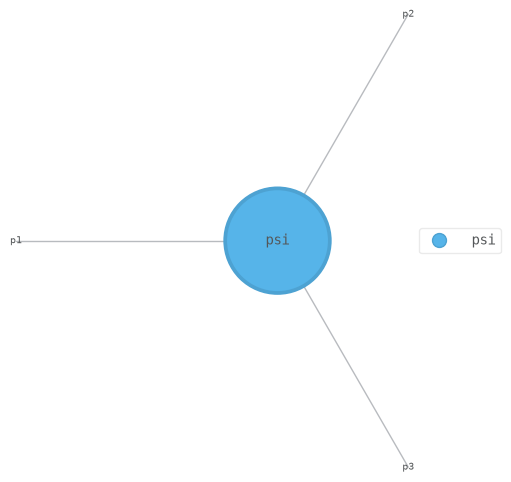

In [9]:
T_psi=qtn.Tensor(psi, inds=['p1', 'p2', 'p3'], tags='psi')
T_psi.draw(color=['psi'])

(2, 2)


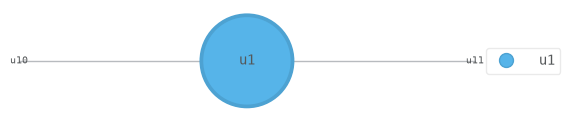

In [10]:
# reshape vector to matrix
psi = np.reshape(psi, (2, 2**(2)))
# SVD to split off first site
U1, Lambda1, Vd1 = np.linalg.svd(psi, full_matrices=False)
Us = []
Us.append(U1)
T_u1=qtn.Tensor(U1, inds=['u10', 'u11'], tags='u1' )
print(U1.shape)
T_u1.draw(color=['u1'])


In [11]:
psi_remainder1 = np.diag(Lambda1) @ Vd1
print(psi_remainder1.shape)                # mu1 (s2 s3)

(2, 4)


(4, 2)
(2, 2, 2)


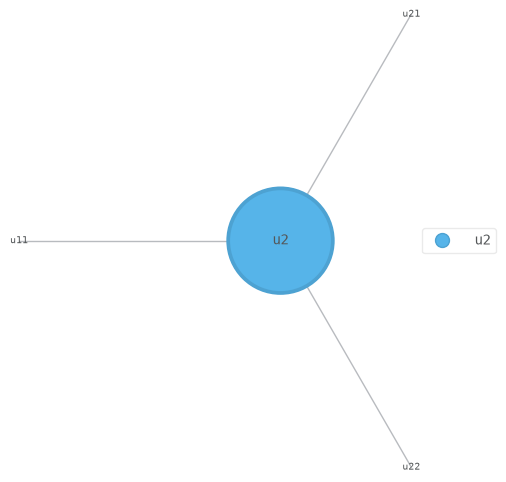

In [12]:
psi_remainder1 = np.reshape(psi_remainder1, (2**2, 2**1))  # (mu1 s2), s3
U2, Lambda2, Vd2 = np.linalg.svd(psi_remainder1, full_matrices=False)
print(U2.shape)
U2 = np.reshape(U2, (2, 2,2))
Us.append(U2)
print(U2.shape)
T_u2=qtn.Tensor(U2, inds=['u11', 'u21', 'u22'], tags='u2' )
T_u2.draw(color=['u2'])

(2, 2)


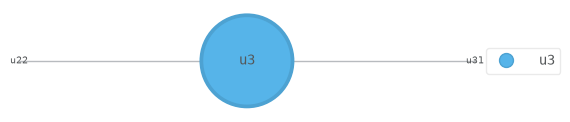

In [13]:
psi_remainder3 = np.diag(Lambda2) @ Vd2
print(psi_remainder3.shape)
Us.append(psi_remainder3)
T_u3=qtn.Tensor(psi_remainder3, inds=['u22', 'u31'], tags='u3' )
T_u3.draw(color=['u3'])

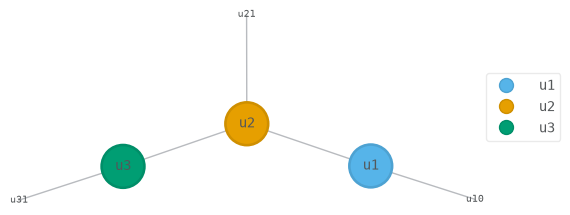

In [14]:
MPS_psi=(T_u1
    & T_u2
    & T_u3
    )
MPS_psi.draw(color=['u1', 'u2', 'u3'])

In [15]:
def split(M, bond_dim):
    """Split a matrix M via SVD and keep only the ``bond_dim`` largest entries."""
    U, S, Vd = np.linalg.svd(M, full_matrices=False)
    bonds = len(S)
    Vd = Vd.reshape(bonds, 2, -1)
    U = U.reshape((-1, 2, bonds))

    # keep only chi bonds
    chi = np.min([bonds, bond_dim])
    U, S, Vd = U[:, :, :chi], S[:chi], Vd[:chi]
    return U, S, Vd

In [16]:
n=4
psi = np.random.rand(*[2]*n)
psi = psi/np.linalg.norm(psi)

In [17]:
def split(M, bond_dim):
    """Split a matrix M via SVD and keep only the ``bond_dim`` largest entries."""
    U, S, Vd = np.linalg.svd(M, full_matrices=False)
    bonds = len(S)
    Vd = Vd.reshape(bonds, 2, -1)
    U = U.reshape((-1, 2, bonds))

    # keep only chi bonds
    chi = np.min([bonds, bond_dim])
    U, S, Vd = U[:, :, :chi], S[:chi], Vd[:chi]
    return U, S, Vd

def dense_to_mps(psi, bond_dim):
    """Turn a state vector ``psi`` into an MPS with bond dimension ``bond_dim``."""
    Ms = []
    Ss = []

    psi = np.reshape(psi, (2, -1))   # split psi[2, 2, 2, 2..] = psi[2, (2x2x2...)]
    U, S, Vd = split(psi, bond_dim)  # psi[2, (2x2x..)] = U[2, mu] S[mu] Vd[mu, (2x2x2x..)]

    Ms.append(U)
    Ss.append(S)
    bondL = Vd.shape[0]
    psi = np.tensordot(np.diag(S), Vd, 1)

    for _ in range(n-2):
        psi = np.reshape(psi, (2*bondL, -1)) # reshape psi[2 * bondL, (2x2x2...)]
        U, S, Vd = split(psi, bond_dim) # psi[2, (2x2x..)] = U[2, mu] S[mu] Vd[mu, (2x2x2x..)]
        Ms.append(U)
        Ss.append(S)

        psi = np.tensordot(np.diag(S), Vd, 1)
        bondL = Vd.shape[0]

    # dummy step on last site
    psi = np.reshape(psi, (-1, 1))
    U, _, _ = np.linalg.svd(psi, full_matrices=False)

    U = np.reshape(U, (-1, 2, 1))
    Ms.append(U)

    return Ms, Ss


n = 12
bond_dim = 10000

psi = np.random.rand(*[2]*n)
psi = psi/np.linalg.norm(psi)
Ms, Ss = dense_to_mps(psi, bond_dim)

[M.shape for M in Ms]

[(1, 2, 2),
 (2, 2, 4),
 (4, 2, 8),
 (8, 2, 16),
 (16, 2, 32),
 (32, 2, 64),
 (64, 2, 32),
 (32, 2, 16),
 (16, 2, 8),
 (8, 2, 4),
 (4, 2, 2),
 (2, 2, 1)]

In [18]:
n = 12
bond_dim = 5

psi = np.random.rand(*[2]*n)
psi = psi/np.linalg.norm(psi)
Ms, Ss = dense_to_mps(psi, bond_dim)

[M.shape for M in Ms]

[(1, 2, 2),
 (2, 2, 4),
 (4, 2, 5),
 (5, 2, 5),
 (5, 2, 5),
 (5, 2, 5),
 (5, 2, 5),
 (5, 2, 5),
 (5, 2, 5),
 (5, 2, 4),
 (4, 2, 2),
 (2, 2, 1)]

You can automatically call mps(s) from quimb's built-in functions.

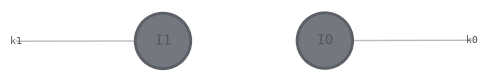

In [19]:
binary='00'
p=qtn.MPS_computational_state(binary, dtype='float64', cyclic=False)
p.draw()

Creating a bell state with MPS:

In [20]:
binary='00' #state you want to prepare
n=len(binary)
p=qtn.MPS_computational_state(binary, dtype='float64', cyclic=False)

p.to_dense()


array([[1.],
       [0.],
       [0.],
       [0.]])

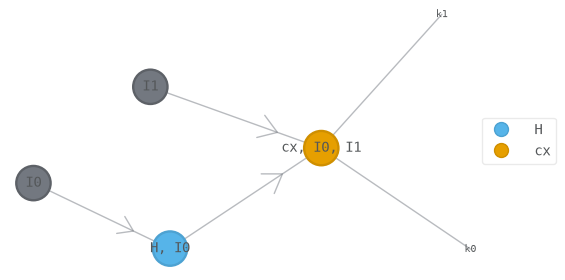

array([[0.70710678+0.j],
       [0.        +0.j],
       [0.        +0.j],
       [0.70710678+0.j]])

In [21]:
H = quimb.hadamard()
cx= quimb.controlled('x')

p.gate_(H, 0, tags='H', contract=False)
p.gate_(cx, (0,1),tags='cx', contract=False)
p.draw(color=['H', 'cx'])
p.to_dense()


# Cannonization


In [22]:
binary='0'*100
H = quimb.hadamard()
p=qtn.MPS_computational_state(binary, dtype='float64', cyclic=False)
p.left_canonize()

q=qtn.MPS_computational_state(binary, dtype='float64', cyclic=False)
q.right_canonize()
q.gate_(H, 50, tags='H', contract=False)


(p & q)^...



np.complex128(0.7071067811865475+0j)

We just did a expectation value calculation with 100 qubits.

# Why use Tensor Network instead of other simulators?

In [23]:
def quimb_product_mps_qft(binary,contract_value_h, contract_value):
    #binary form of product-type initial state in computational basis
    n=len(binary)
    p=qtn.MPS_computational_state(binary, dtype='float64', cyclic=False)

    H = quimb.hadamard()
    swap = np.array(quimb.swap())


    for i in reversed(np.arange(n)):
        p.gate_(H, i, tags='H', contract=contract_value_h)
        for j in reversed(np.arange(i)):
            phase= 1/2**(i-j)
            cphase = np.array(quimb.controlled('z')) ** phase
            p.gate_(cphase, (j, i), tags='CP', max_bond=2, contract=contract_value)


    #Swap gates
    for i in range(int(n/2)):
        p.gate_(swap, (i, n-(i+1)), tags='Swap', max_bond=2, contract=contract_value)

    return p

In [24]:
def quimb_mps_qft_approximate(binary, contract_value_h,contract_value):
    #binary form of product-type initial state in computational basis
    n=len(binary)
    p=qtn.MPS_computational_state(binary, dtype='float64', cyclic=False)

    H = quimb.hadamard()
    swap = np.array(quimb.swap())


    for i in reversed(np.arange(n)):
        p.gate_(H, i, tags='H', contract=contract_value_h)
        for j in reversed(np.arange(i)):
            if (i-j)<= 5:
                phase= 1/2**(i-j)

                cphase = np.array(quimb.controlled('z')) ** phase
                p.gate_(cphase, (j, i), tags='CP', max_bond=2, contract=contract_value)


    #Swap gates
    for i in range(int(n/2)):
        p.gate_(swap, (i, n-(i+1)), tags='Swap', max_bond=2, contract=contract_value)

    return p

In [28]:
n=30
p=quimb_product_mps_qft('1'*n, True,'swap+split')
q=quimb_mps_qft_approximate('1'*n,True, 'swap+split')
fid=np.abs((p.H & q)^...)**2

print(fid)

0.9475888487472229
